#### Test order generation

In [3]:
import random

def generate_random_partition(total_sum, num_parts):
    dividers = sorted(random.randint(0, total_sum) for _ in range(num_parts - 1))
    points = [0] + dividers + [total_sum]
    return [points[i+1] - points[i] for i in range(num_parts)]

def generate_test_orders_of_boxamt(boxamt):
    for row_id in range(boxamt*100, boxamt*100+100):
        values = generate_random_partition(boxamt, 10)
        row_data = [row_id] + values
        print(",".join(map(str, row_data)))

for boxamt in range(0):
    generate_test_orders_of_boxamt(boxamt)

#### BnB Algorithm csv data processing

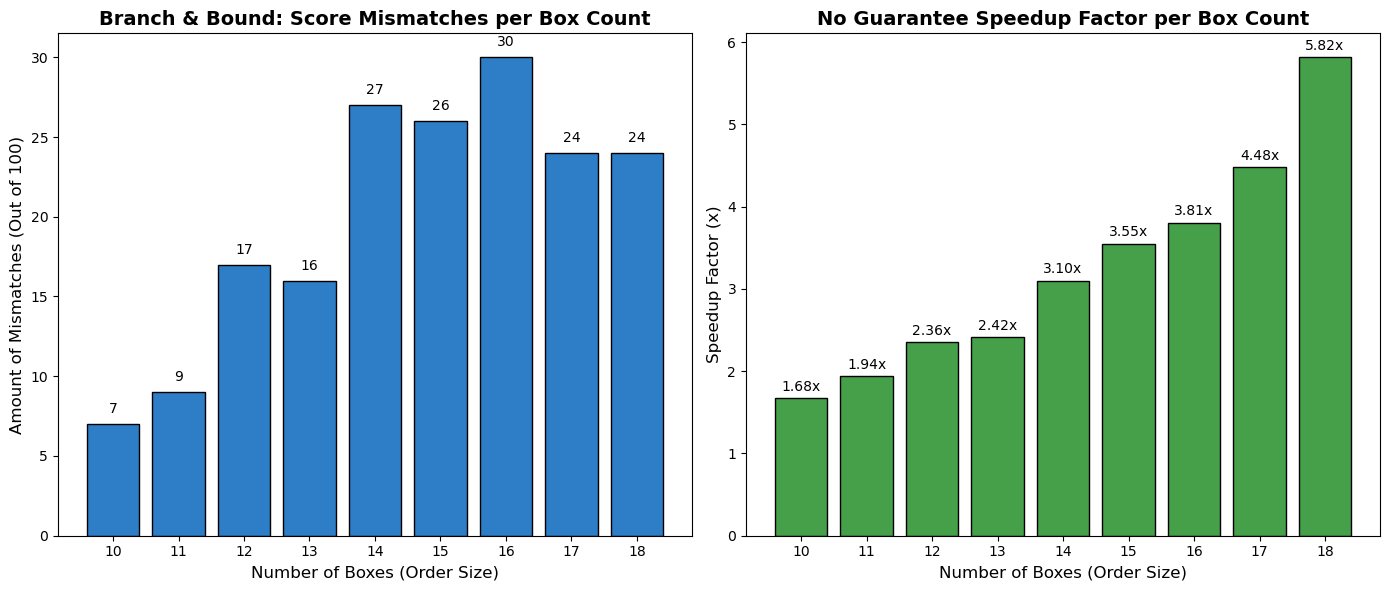

In [5]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

PRINT_MODE = False
SAVE_MODE = False

directory = './results/bnb_comparisons'
csv_files = glob.glob(os.path.join(directory, '*.csv'))
results_dict = {}

for filepath in csv_files:
    filename = os.path.basename(filepath)
    box_count = filename[25:27]
    df = pd.read_csv(filepath)

    if PRINT_MODE:
        print(f"\n--- Analysis of {box_count}-box orders ---")
    
    # Initialize the dictionary for this box group
    results_dict[box_count] = {
        'completeness_status': 'good',
        'mismatch_count': 0,
        'avg_score_diff': 0.0,
        'percent_improvement': None,
        'speed_multiplier': None
    }
    
    # Missing data: check all non- *_factor columns for missing values
    cols_to_check = [c for c in df.columns if not c.endswith('_factor')]
    missing_data_cols = df[cols_to_check].isnull().any(axis=1)

    if len(df) == 100 and not missing_data_cols.any():
        if PRINT_MODE:
            print("- Completeness:                 good")
    else:
        results_dict[box_count]['completeness_status'] = '!missing data!'
        print(f"- Completeness:                 !missing data!")
        if len(df) != 100:
            print(f"    !! File contains {len(df)}/100 rows !!")
        if missing_data_cols.any():
            missing_ids = df[missing_data_cols]['order_id'].tolist()
            print(f"    !! Missing data in order IDs:")
            print(f"      {missing_ids}")

    # Count guarantee on/off score mismatches in orders
    mismatches = df[df['score_no_guarantee'] != df['score_with_guarantee']]
    mismatch_count = len(mismatches)
    results_dict[box_count]['mismatch_count'] = mismatch_count
    
    if mismatch_count > 0:
        avg_score_diff = abs(mismatches['score_no_guarantee'] - mismatches['score_with_guarantee']).mean()
        results_dict[box_count]['avg_score_diff'] = avg_score_diff
        if PRINT_MODE:
            print(f"- Score mismatches:             {mismatch_count}")
            print(f"- Average mismatch size:        {avg_score_diff:.2f}")
    else:
        if PRINT_MODE:
            print("- Score mismatches:             none")

    # Node evaluation number comparison
    df['nodes_diff_factor'] = pd.to_numeric(df['nodes_diff_factor'])
    avg_diff_factor = df['nodes_diff_factor'].mean()
    
    if pd.notna(avg_diff_factor) and avg_diff_factor > 0:
        percent_improvement = (1 - avg_diff_factor) * 100
        times_fewer = 1 / avg_diff_factor
        
        results_dict[box_count]['percent_improvement'] = percent_improvement
        results_dict[box_count]['speed_multiplier'] = times_fewer
        
        if PRINT_MODE:
            print(f"- Node improvement:             {percent_improvement:.2f}%")
            print(f"- No guarantee speedup:         {times_fewer:.2f}x")
    else:
        print("- Node improvement:             !error!")

# Sort the dictionary by box_count
sorted_items = sorted(results_dict.items(), key=lambda x: int(x[0]) if x[0].isdigit() else x[0])

# Extract data for plotting
box_counts_list = [item[0] for item in sorted_items]
mismatch_counts_list = [item[1]['mismatch_count'] for item in sorted_items]
speedup_list = [item[1]['speed_multiplier'] for item in sorted_items]

# Create the plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Mismatch graph
ax1.bar(box_counts_list, mismatch_counts_list, color='#2e7dc7', edgecolor='black')
ax1.set_title('Branch & Bound: Score Mismatches per Box Count', fontsize=14, fontweight='bold')
ax1.set_xlabel('Number of Boxes (Order Size)', fontsize=12)
ax1.set_ylabel('Amount of Mismatches (Out of 100)', fontsize=12)

# Display the exact number on top of each bar
for index, value in enumerate(mismatch_counts_list):
    ax1.text(index, value + 0.5, str(value), ha='center', va='bottom', fontsize=10)

# Speedup graph
ax2.bar(box_counts_list, speedup_list, color='#45a049', edgecolor='black')
ax2.set_title('No Guarantee Speedup Factor per Box Count', fontsize=14, fontweight='bold')
ax2.set_xlabel('Number of Boxes (Order Size)', fontsize=12)
ax2.set_ylabel('Speedup Factor (x)', fontsize=12)

# Display exact numbers on top of each bar
for index, value in enumerate(speedup_list):
    if value > 0:
        ax2.text(index, value + 0.05, f"{value:.2f}x", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Save the figure if SAVE_MODE is True
if SAVE_MODE:
    save_path = './results/bnb_performance_summary.png'
    plt.savefig(save_path, dpi=300)
    if PRINT_MODE:
        print(f"\n[INFO] Figure successfully saved to: {save_path}")